In [19]:
import os
import pandas as pd
# use polars when using very large dataframes as polars is faster than pandas
import polars as pl
import numpy as np
# use pickle to save and load data objects (when saving a df using pickle, you save more information)
import pickle
import matplotlib.pyplot as plt

# With the ic() method you can print something that is between the brackets and automatically also print its name
from icecream import ic


## Load the history-per-year dataset

In [20]:
# Read the Parquet file using Pandas
# df = pd.read_parquet("C:/Users/jasmi/Documents/2025_Data_analyse/2025_03_Group_project_Supermarket/Data/data/history-per-year.parquet")

# print("The columns names are:", df.columns)
# print(f'the number of columns is {len(df.columns)}')


# Read the Parquet file using polars
df_polars = pl.read_parquet("C:/Users/jasmi/Documents/2025_Data_analyse/2025_03_Group_project_Supermarket/Data/data/history-per-year.parquet")

print("The columns names are:", df_polars.columns)
print(f'the number of columns is {len(df_polars.columns)}')


The columns names are: ['id', 'store_nbr', 'item_nbr', 'unit_sales', 'onpromotion', 'day', 'year', 'month']
the number of columns is 8


## Give the data type for each column and count the number of observations

In [21]:
# Extract the column names
# columns = df.columns

# Show column names and their datatypes
# for column, dtype in df.dtypes.items():
    # print(f"Column: {column}, DataType: {dtype}")

# print(f'the number of observations is {df.shape[0]}')
# df.head(10)

# The same with the polars df:
nr_observations_million = df_polars.shape[0]/10000000
print(f'The number of observations is {nr_observations_million:.2f} million')
    
# Show column names and their datatypes using Polars
for column in df_polars.columns:
   print(f"Column: {column}, DataType: {df_polars[column].dtype}")


The number of observations is 12.55 million
Column: id, DataType: UInt32
Column: store_nbr, DataType: UInt8
Column: item_nbr, DataType: UInt32
Column: unit_sales, DataType: Float64
Column: onpromotion, DataType: Boolean
Column: day, DataType: UInt8
Column: year, DataType: Int64
Column: month, DataType: Int64


## Show the tops and bottom rows of the history-per-year dataframe

In [22]:
df_polars.head(10)
df_polars.head(-10)

id,store_nbr,item_nbr,unit_sales,onpromotion,day,year,month
u32,u8,u32,f64,bool,u8,i64,i64
0,25,103665,7.0,null,1,2013,1
1,25,105574,1.0,null,1,2013,1
2,25,105575,2.0,null,1,2013,1
3,25,108079,1.0,null,1,2013,1
4,25,108701,1.0,null,1,2013,1
…,…,…,…,…,…,…,…
125497025,54,2081064,49.0,false,15,2017,8
125497026,54,2081095,3.0,false,15,2017,8
125497027,54,2081161,41.0,false,15,2017,8


## Count the number of missing values per variable


In [23]:
# Count missing values per column
# missing_values = df.isnull().sum()

# print("Number of missing values per column:")
# print(missing_values)

# Count missing values per column using Polars:
missing_values = df_polars.select(
    [pl.col(col).is_null().sum().alias(col) for col in df_polars.columns])

print("Number of missing values per column:")
print(missing_values)


Number of missing values per column:
shape: (1, 8)
┌─────┬───────────┬──────────┬────────────┬─────────────┬─────┬──────┬───────┐
│ id  ┆ store_nbr ┆ item_nbr ┆ unit_sales ┆ onpromotion ┆ day ┆ year ┆ month │
│ --- ┆ ---       ┆ ---      ┆ ---        ┆ ---         ┆ --- ┆ ---  ┆ ---   │
│ u32 ┆ u32       ┆ u32      ┆ u32        ┆ u32         ┆ u32 ┆ u32  ┆ u32   │
╞═════╪═══════════╪══════════╪════════════╪═════════════╪═════╪══════╪═══════╡
│ 0   ┆ 0         ┆ 0        ┆ 0          ┆ 21657651    ┆ 0   ┆ 0    ┆ 0     │
└─────┴───────────┴──────────┴────────────┴─────────────┴─────┴──────┴───────┘


# Let's try some visualisations

#

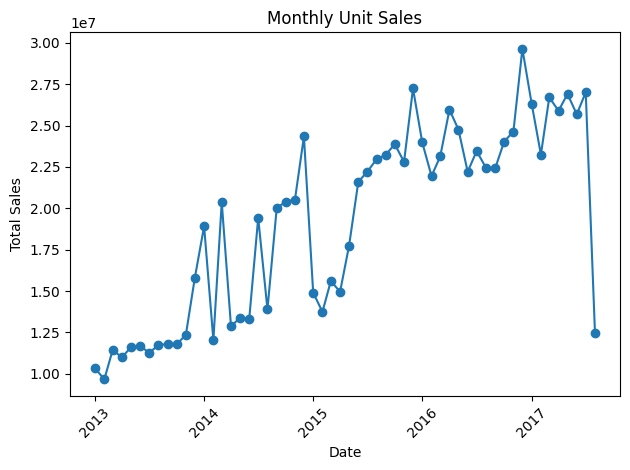

In [24]:
# Step 1: Convert Polars DataFrame to pandas DataFrame
df_pandas = df_polars.to_pandas()

# Step 3: Group and aggregate in pandas
monthly_sales = df_pandas.groupby(["year", "month"]).agg({
    "unit_sales": "sum"
}).reset_index()

# Step 4: Create a datetime column for visualization
monthly_sales["date"] = pd.to_datetime(
    monthly_sales["year"].astype(str) + "-" + monthly_sales["month"].astype(str) + "-01"
)

# Step 5: Plot the grouped data
plt.plot(monthly_sales["date"], monthly_sales["unit_sales"], marker="o")
plt.title("Monthly Unit Sales")
plt.xlabel("Date")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


## Load the history_aggregated dataset 

In [ ]:
# Read the Parquet file using Pandas
# df_aggregated = pd.read_parquet("C:/Users/jasmi/Documents/2025_Data_analyse/2025_03_Group_project_Supermarket/Data/data/history_aggregated.parquet")

# print("The columns names of the aggregated dataset are:", df_aggregated.columns)
# print(f'the number of columns is {len(df_aggregated.columns)}')


# Read the Parquet file using polars
df_aggregated_polars = pl.read_parquet("C:/Users/jasmi/Documents/2025_Data_analyse/2025_03_Group_project_Supermarket/Data/data/history_aggregated.parquet")

print("The columns names of the aggregated dataset are:", df_aggregated_polars.columns)
print(f'the number of columns in the aggregated dataset is {len(df_aggregated_polars.columns)}')

##  Give the data type for each column and count the number of observations

In [ ]:
# Extract the column names
# columns = df_aggregated.columns

# Show column names and their datatypes
# for column, dtype in df_aggregated.dtypes.items():
    # print(f"Column: {column}, DataType: {dtype}")

# print(f'the number of observations is {df_aggregated.shape[0]}')
# df.head(10)

# The same with the polars df:
nr_observations_million = df_aggregated_polars.shape[0]/10000000
print(f'The number of observations is {nr_observations_million:.2f} million')
    
# Show column names and their datatypes using Polars
for column in df_aggregated_polars.columns:
   print(f"Column: {column}, DataType: {df_aggregated_polars[column].dtype}")


## Show the tops and bottom rows of the history-per-year dataframe

In [ ]:
df_aggregated_polars.head(10)
df_aggregated_polars.head(-10)

## Count the number of missing values per variable in the history_per_year dataframe

In [ ]:
# Count missing values per column
# missing_values = df_aggregated.isnull().sum()

# print("Number of missing values per column:")
# print(missing_values)

# Count missing values per column using Polars:
missing_values = df_aggregated_polars.select(
    [pl.col(col).is_null().sum().alias(col) for col in df_aggregated_polars.columns])

print("Number of missing values per column:")
print(missing_values)

In [ ]:
# Print all unique values in of the family column
column_name = 'family'
unique_values = set(df_aggregated_polars[column_name].to_list())
print(f"Unique values in column '{column_name}':")
print(unique_values)



## Conduct descriptive/summary statistics for numerical variables (e.g., mean, median, std, and range)

In [ ]:
range_values = df_num.max() - df_num.min()
df_num_sum=pd.DataFrame(range_values)
df_num_sum.columns=['range']
df_num_sum['median_values'] = df_num.median()
df_num_sum['mean']=df_num.mean()
df_num_sum['std']=df_num.std()

print(df_num_sum)


In [ ]:
unique_counts = df_string.nunique()
df_string_sum=pd.DataFrame(unique_counts)
df_string_sum.columns = ['unique counts']
print(df_string_sum)

## Conduct descriptive/summary statistics for string variables (e.g., number of unique values, mode, and their frequency)

In [ ]:
df_string.describe()

## Give all modes for string variables (is the same as top in the above cell)

In [ ]:
for column in df_string.columns:
    mode_value = df_string[column].mode()[0]
    print(f'The mode of column {column} is: {mode_value}')

## Exercise 3: a. Impute the numerical variables with the median value of the available data.

In [ ]:
df_imputed_num = df_num.replace(np.nan, df_num.median())
# alternative - see solutions file -> with fillna


print(
    f"The imputed numerical data has {df_imputed_num.isnull().sum().sum()} "
    f"missing values."
)

## 3b1. Impute the string variables with the label "other".

In [ ]:
s_replace_by = "other"
df_imputed_string = df_string.replace(np.nan, s_replace_by)
print(
    f"The imputed string data has {df_imputed_string.isnull().sum().sum()} "
    f"missing values."
)

## b2. Alternatively, impute the string variables with the mode (most frequent value) of the available data. In case you use Pandas, why does df_name.mode() result in a data frame with two rows?

In [ ]:
print(df_string.mode())
# in case there is another value with the same abundancy as the one of the first row, it is shown in the second row

df_imputed_string_mode = df_string.fillna(df_string.mode().iloc[0])


## c. Concatenate the imputed numerical (a.) and string (b2.) data frame into a single data frame.

In [ ]:
df_imputed = pd.concat([df_imputed_string_mode, df_imputed_num], axis=1)
# axis=1 means that you concatenate horizontally, so the number of rows remains the same and the column number is the sum of the column numbers

print(df_imputed.shape, df.shape)

## Reduce memory usage by converting string type data to category type and downcast numerical data to their smallest container size

In [ ]:
# Make a copy of the imputed df
df_reduced = df_imputed.copy(deep=False)

# Column names (Pandas: df_pd_orig_str.columns.tolist()).
l_df_str_names = df_string.columns.tolist()
l_df_num_names = df_num.columns.tolist()

# convert the strings to 'Category' tpe variables
df_reduced[l_df_str_names] = (
    df_reduced[l_df_str_names]
    .astype('category'))

# convert the numerical variables to downcasted ones:
for old, new in zip(['integer', 'float'], ['unsigned', 'float']):

    for s_col in df_reduced.select_dtypes(include=old).columns:
        
        df_reduced[s_col] = pd.to_numeric(df_reduced[s_col], downcast=new)

par1 = df.memory_usage().sum()/(1024**2)
par2 = df_imputed.memory_usage().sum()/(1024**2)
par3 = df_reduced.memory_usage().sum()/(1024**2)

print(f"Size of original data frame               : {round(par1, 1)} MB.")
print(f"Size of imputed data frame                : {round(par2, 1)} MB.")
print(f"Size of imputed and downcasted data frame : {round(par3, 2)} MB.")
print(f"Reduced original data frame by factor of  : {round(par1/par3)}")

## Save object files with pickle

In [ ]:
# Create dictionary 'dc_exercise_1_2_3' with objects that will be used in the next exercises.
dc_exercise_1_2_3 = {
    'df_pd_orig':      df,
    'df_reduced':   df_reduced,
    'l_df_num_names':  l_df_num_names,
    'l_df_str_names':  l_df_str_names,
}

# Save dc_exercise_1_2_3 as 'dc-ames-housing-joran-exercise-1-2-3.pkl'
with open('../Data/dc-ames-housing-joran-exercise-1-2-3.pkl', 'wb') as pickle_file:
    pickle.dump(dc_exercise_1_2_3, pickle_file)